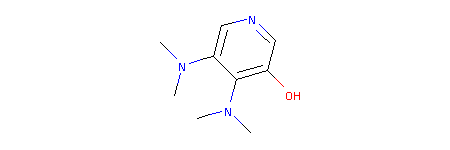

In [31]:
from rdkit import Chem
from rdkit.Chem.Draw import IPythonConsole
from rdkit.Chem import Draw
import pickle
import matplotlib.pyplot as plt
import torch
import numpy as np
from dqn import MolDQN
from rdkit.Chem import QED
from beautifultable import BeautifulTable, BTRowCollection
from prettytable import PrettyTable

import pandas as pd
import pickle
import joblib
# from molbert.utils.featurizer.molbert_featurizer import MolBertFeaturizer

from rdkit import RDConfig
import os
import sys
sys.path.append(os.path.join(RDConfig.RDContribDir, 'SA_Score'))
import sascorer

from rdkit.DataManip.Metric import GetTanimotoDistMat
from rdkit.DataManip.Metric import GetTanimotoSimMat

IPythonConsole.ipython_useSVG=True
import random
from rdkit.Chem import AllChem

Chem.MolFromSmiles('CN(C)c1cncc(O)c1N(C)C')

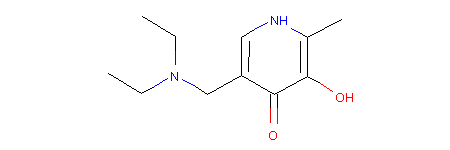

In [2]:
mol = Chem.MolFromSmiles('CCN(CC)Cc1c[nH]c(C)c(O)c1=O') # public mols
mol

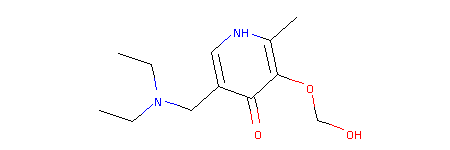

In [5]:
mol = Chem.MolFromSmiles('CCN(CC)Cc1c[nH]c(C)c(OCO)c1=O') # public mols
mol

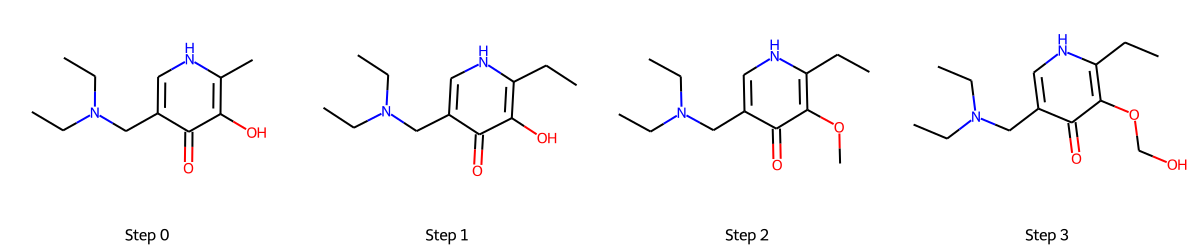

In [11]:
s = ['CCN(CC)Cc1c[nH]c(C)c(O)c1=O', 'CCN(CC)Cc1c[nH]c(CC)c(O)c1=O','CCN(CC)Cc1c[nH]c(CC)c(OC)c1=O', 'CCN(CC)Cc1c[nH]c(CC)c(OCO)c1=O']
l = ['Step 0', 'Step 1', 'Step 2', 'Step 3']
mols = [Chem.MolFromSmiles(mol) for mol in s]
Draw.MolsToGridImage([mol for mol in mols], legends=l, molsPerRow=4, subImgSize=(300, 250)) 

In [41]:
def mol_with_atom_index(mol):
    for atom in mol.GetAtoms():
        if atom.GetIdx() == 19 or atom.GetIdx() == 6 or True:
            atom.SetAtomMapNum(atom.GetIdx())
    return mol

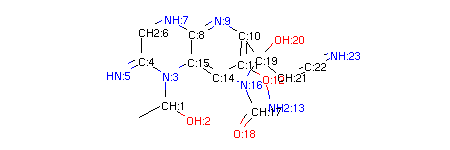

In [42]:
# s = 'Cn1cc(C2=C(c3coc4ccccc34)C(=O)NC2=O)c2ccc(O)cc21'
# s = 'CN(C#N)C1=CN2c3c(cnc4nc5n(c34)C(O)=CC52OCO)O1'
# mol = Chem.MolFromSmiles(s)
mol = Chem.MolFromSmiles("CC(O)N1C(=N)CNc2nc3c(ON)c(c21)N(C=O)C3(O)C=C=N")
r = Chem.RWMol(mol)
# r.AddBond(1,10, Chem.BondType.SINGLE)
# r
mol_with_atom_index(r)

In [44]:
# s = 'CN(C#N)C1=CN2c3c(cnc4nc5n(c34)C(O)=CC52OCO)O1'
mol = Chem.MolFromSmiles("CC(O)N1C(=N)CNc2nc3c(ON)c(c21)N(C=O)C3(O)C=C=N")

# mol = Chem.MolFromSmiles(s)
r = Chem.RWMol(mol)
# r.AddBond(0,16, Chem.BondType.SINGLE)
r.RemoveBond(16, 19)
# r
print(Chem.MolToSmiles(r))
# mol_with_atom_index(r)

CC(O)N1C(=N)CNc2nc(C(O)C=C=N)c(ON)c(NC=O)c21


In [34]:
mol = Chem.AddHs(r)
cid = 0
try:
    cid = AllChem.EmbedMolecule(mol, useRandomCoords=True)
except Exception as e:
    print("Exception: ")
    print(e)
    print("F")
if cid == -1:
    print("F - 1")

Exception: 
Explicit valence for atom # 0 C, 5, is greater than permitted
F


[12:23:44] Explicit valence for atom # 0 C, 5, is greater than permitted
RDKit ERROR: [12:23:44] Explicit valence for atom # 0 C, 5, is greater than permitted
